### Size issue 
That file size of 28.45 GB for a single-cell RNA-seq .h5ad dataset is very large.

Memory (RAM): A 28 GB .h5ad file, which typically contains a sparse matrix of UMI counts, will require a substantial amount of RAM when loaded and processed. When the data is converted to a dense matrix or intermediate processing steps are performed (like calculating nearest neighbors, running PCA, etc.), the memory footprint can easily exceed 100-200 GB.

Processing Time: Even with sufficient RAM, a dataset of this size (likely involving millions of cells) will result in long processing times for any single-cell workflow, particularly for computationally intensive steps like training a large neural network model such as GenFormer.

In [1]:
import os
import scanpy as sc
import anndata as ad
import pandas as pd
import cellxgene_census
from sklearn.metrics import normalized_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

In [2]:
 adata = sc.read_h5ad('/projects/bioinformatics/DB/scRNAseq_parkinson/terra_file/amppd_merged_snRNAseq.h5ad')

In [2]:
 adata_an = sc.read_h5ad('/projects/bioinformatics/DB/scRNAseq_parkinson/terra_file/amppd_merged_snRNAseq_annotated.h5ad')

In [5]:
 adata_re = sc.read_h5ad('/projects/bioinformatics/DB/scRNAseq_parkinson/terra_file/amppd_merged_snRNAseq_retracted_20240202.h5ad')

In [11]:
adata

AnnData object with n_obs × n_vars = 2441192 × 40496
    obs: 'sample_id', 'participant_id'
    uns: 'genome', 'modality', 'uid', 'var_dict'

In [10]:
# this is the one that we need to utilise 
adata_an

AnnData object with n_obs × n_vars = 2096155 × 40496
    obs: 'sample_id', 'participant_id', 'cell_type'
    uns: 'genome', 'modality', 'uid', 'var_dict'

In [9]:
adata_re

AnnData object with n_obs × n_vars = 2441192 × 40496
    obs: 'sample_id', 'participant_id'
    uns: 'genome', 'modality', 'var_dict'

In [3]:
braak = pd.read_csv("/projects/bioinformatics/DB/scRNAseq_parkinson/terra_file/clinical_Terra_2024_v4_release_1027/LBD_Cohort_Path_Data.csv")

In [4]:
braak

,participant_id,GUID,visit_name,visit_month,path_cerad,path_braak_nft,path_braak_lb,path_dlb_prob
0,LB-00001,NaN,M0,0,NaN,NaN,NaN,NaN
1,LB-00002,NaN,M0,0,NaN,NaN,NaN,NaN
2,LB-00003,NaN,M0,0,NaN,NaN,NaN,NaN
3,LB-00004,NaN,M0,0,NaN,NaN,NaN,NaN
4,LB-00005,NaN,M0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2609,PM-UM_BEB20006,NaN,M0,0,NaN,1.0,4.0,Intermediate Likelihood
2610,PM-UM_HTM,NaN,M0,0,NaN,2.0,5.0,NaN
2611,PM-UM_HCTZZL,NaN,M0,0,NaN,1.0,NaN,NaN
2612,PM-UM_HCTZZM,NaN,M0,0,NaN,2.0,NaN,NaN


In [5]:
len(adata_an.obs['participant_id'].unique())

97

In [6]:
# getting unique column ID 

participant_ids = adata_an.obs['participant_id'].unique()

In [7]:
participant_ids

['PM-UM_BEB19139', 'PM-UD_11485_001', 'PM-UD_1052_001', 'PM-MS_841919', 'PM-UM_BEB20014', ..., 'PM-HA_S06947', 'PM-HA_S16298', 'PM-HA_S07792', 'PM-MS_971551', 'PM-MS_56356']
Length: 97
Categories (97, object): ['PM-UM_BEB18119', 'PM-UM_BEB18140', 'PM-UM_BEB19010', 'PM-UM_BEB19108', ..., 'PM-HA_S16962', 'PM-HA_S18739', 'PM-HA_S19010', 'PM-HA_S19871']

In [8]:
braak.columns

Index(['participant_id', 'GUID', 'visit_name', 'visit_month', 'path_cerad',
       'path_braak_nft', 'path_braak_lb', 'path_dlb_prob'],
      dtype='object')

In [9]:
# filter the clinical data

braak_filtered = braak[braak['participant_id'].isin(participant_ids)]

In [12]:
data_i = braak_filtered.sort_index()

In [13]:
data_i

,participant_id,GUID,visit_name,visit_month,path_cerad,path_braak_nft,path_braak_lb,path_dlb_prob
2521,PM-HA_S00447,NaN,M0,0,NaN,1.0,5.0,NaN
2522,PM-HA_S00781,NaN,M0,0,NaN,1.0,5.0,NaN
2523,PM-HA_S01646,NaN,M0,0,NaN,1.0,5.0,NaN
2524,PM-HA_S01667,NaN,M0,0,NaN,1.0,4.0,NaN
2525,PM-HA_S02252,NaN,M0,0,NaN,2.0,4.0,NaN
...,...,...,...,...,...,...,...,...
2609,PM-UM_BEB20006,NaN,M0,0,NaN,1.0,4.0,Intermediate Likelihood
2610,PM-UM_HTM,NaN,M0,0,NaN,2.0,5.0,NaN
2611,PM-UM_HCTZZL,NaN,M0,0,NaN,1.0,NaN,NaN
2612,PM-UM_HCTZZM,NaN,M0,0,NaN,2.0,NaN,NaN


# analysing the data nft and lb 

In [15]:
data_i["path_braak_lb"].value_counts()


path_braak_lb
4.0    24
5.0    21
3.0    18
6.0     7
0.0     7
1.0     4
2.0     4
Name: count, dtype: int64

In [16]:
data_i["path_braak_nft"].value_counts()

path_braak_nft
1.0    38
2.0    23
3.0    15
0.0     6
Name: count, dtype: int64

In [17]:
# Define groups (VERY useful)
high_lb = data_i[data_i["path_braak_lb"] >= 4]
low_lb  = data_i[data_i["path_braak_lb"] < 4]

In [18]:
high_lb

,participant_id,GUID,visit_name,visit_month,path_cerad,path_braak_nft,path_braak_lb,path_dlb_prob
2521,PM-HA_S00447,NaN,M0,0,NaN,1.0,5.0,NaN
2522,PM-HA_S00781,NaN,M0,0,NaN,1.0,5.0,NaN
2523,PM-HA_S01646,NaN,M0,0,NaN,1.0,5.0,NaN
2524,PM-HA_S01667,NaN,M0,0,NaN,1.0,4.0,NaN
2525,PM-HA_S02252,NaN,M0,0,NaN,2.0,4.0,NaN
2529,PM-HA_S05527,NaN,M0,0,NaN,1.0,4.0,NaN
2530,PM-HA_S05887,NaN,M0,0,NaN,2.0,5.0,NaN
2531,PM-HA_S06947,NaN,M0,0,NaN,1.0,4.0,NaN
2532,PM-HA_S07532,NaN,M0,0,NaN,1.0,4.0,NaN
2534,PM-HA_S07792,NaN,M0,0,NaN,1.0,4.0,NaN


In [19]:
low_lb

,participant_id,GUID,visit_name,visit_month,path_cerad,path_braak_nft,path_braak_lb,path_dlb_prob
2526,PM-HA_S02971,NaN,M0,0,NaN,2.0,3.0,NaN
2528,PM-HA_S04610,NaN,M0,0,NaN,1.0,2.0,NaN
2533,PM-HA_S07555,NaN,M0,0,NaN,1.0,3.0,NaN
2539,PM-HA_S14032,NaN,M0,0,NaN,1.0,3.0,NaN
2541,PM-HA_S16580,NaN,M0,0,NaN,1.0,3.0,NaN
2544,PM-HA_S19010,NaN,M0,0,NaN,1.0,3.0,NaN
2546,PM-MS_17629,NaN,SC#1,-5,NaN,1.0,2.0,Low Likelihood
2547,PM-MS_46475,NaN,SC#1,-1,NaN,1.0,1.0,Low Likelihood
2548,PM-MS_458379,NaN,SC#1,-4,NaN,1.0,1.0,Low Likelihood
2550,PM-MS_840752,NaN,SC#1,-1,NaN,1.0,1.0,Low Likelihood


In [20]:
# Tau severity:
high_tau = data_i[data_i["path_braak_nft"] >= 3]
low_tau  = data_i[data_i["path_braak_nft"] < 3]

In [21]:
high_tau

,participant_id,GUID,visit_name,visit_month,path_cerad,path_braak_nft,path_braak_lb,path_dlb_prob
2535,PM-HA_S08385,NaN,M0,0,NaN,3.0,4.0,NaN
2552,PM-MS_38636,NaN,SC#1,-9,NaN,3.0,3.0,Low Likelihood
2556,PM-MS_6130,NaN,SC#1,-3,NaN,3.0,5.0,Low Likelihood
2572,PM-UD_11609_001,NaN,M0,0,NaN,3.0,3.0,NaN
2578,PM-UD_11363_001,NaN,M0,0,NaN,3.0,5.0,NaN
2579,PM-UD_11398_001,NaN,M0,0,NaN,3.0,5.0,NaN
2581,PM-UD_11466_001,NaN,M0,0,NaN,3.0,5.0,NaN
2582,PM-UD_11494_001,NaN,M0,0,NaN,3.0,5.0,NaN
2583,PM-UD_11610_001,NaN,M0,0,NaN,3.0,6.0,NaN
2585,PM-UD_11701_001,NaN,M0,0,NaN,3.0,5.0,NaN


In [22]:
def classify(row):
    if row["path_braak_lb"] >= 4 and row["path_braak_nft"] < 3:
        return "LB-dominant"
    elif row["path_braak_nft"] >= 3 and row["path_braak_lb"] < 4:
        return "Tau-dominant"
    elif row["path_braak_lb"] >= 4 and row["path_braak_nft"] >= 3:
        return "Mixed"
    else:
        return "Low pathology"

data_i["path_group"] = data_i.apply(classify, axis=1)

In [23]:
data_i

,participant_id,GUID,visit_name,visit_month,path_cerad,path_braak_nft,path_braak_lb,path_dlb_prob,path_group
2521,PM-HA_S00447,NaN,M0,0,NaN,1.0,5.0,NaN,LB-dominant
2522,PM-HA_S00781,NaN,M0,0,NaN,1.0,5.0,NaN,LB-dominant
2523,PM-HA_S01646,NaN,M0,0,NaN,1.0,5.0,NaN,LB-dominant
2524,PM-HA_S01667,NaN,M0,0,NaN,1.0,4.0,NaN,LB-dominant
2525,PM-HA_S02252,NaN,M0,0,NaN,2.0,4.0,NaN,LB-dominant
...,...,...,...,...,...,...,...,...,...
2609,PM-UM_BEB20006,NaN,M0,0,NaN,1.0,4.0,Intermediate Likelihood,LB-dominant
2610,PM-UM_HTM,NaN,M0,0,NaN,2.0,5.0,NaN,LB-dominant
2611,PM-UM_HCTZZL,NaN,M0,0,NaN,1.0,NaN,NaN,Low pathology
2612,PM-UM_HCTZZM,NaN,M0,0,NaN,2.0,NaN,NaN,Low pathology


# Plots 

In [24]:
df_plot = data_i.dropna(subset=["path_braak_lb"])

In [25]:
lb_counts = df_plot["path_braak_lb"].value_counts().sort_index()

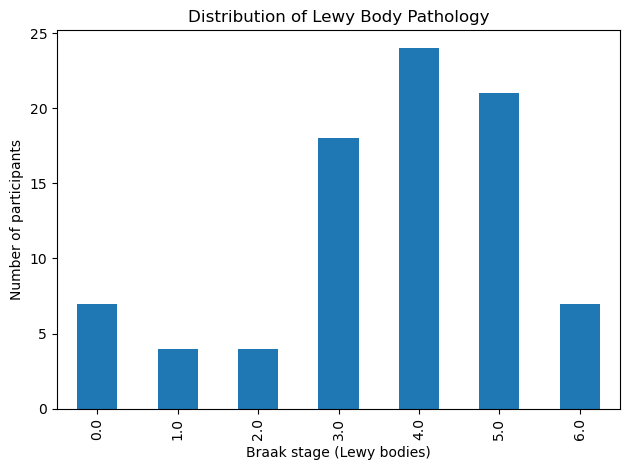

In [26]:
import matplotlib.pyplot as plt

plt.figure()
lb_counts.plot(kind="bar")

plt.xlabel("Braak stage (Lewy bodies)")
plt.ylabel("Number of participants")
plt.title("Distribution of Lewy Body Pathology")

plt.tight_layout()
plt.show()

In [28]:
df_plot2 = data_i.dropna(subset=["path_braak_nft"])

In [29]:
nft_counts = df_plot2["path_braak_nft"].value_counts().sort_index()

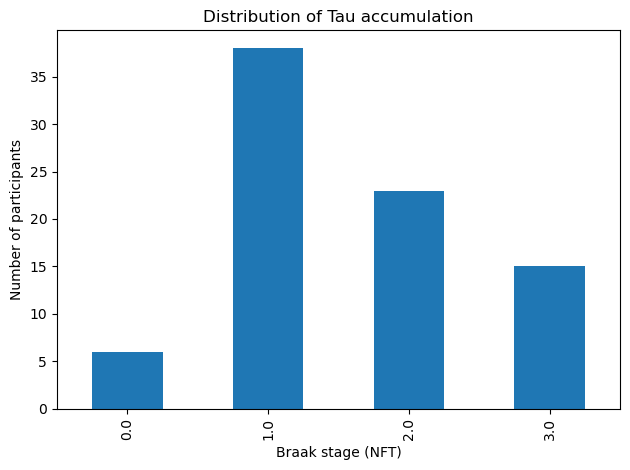

In [30]:
plt.figure()
nft_counts.plot(kind="bar")

plt.xlabel("Braak stage (NFT)")
plt.ylabel("Number of participants")
plt.title("Distribution of Tau accumulation")

plt.tight_layout()
plt.show()

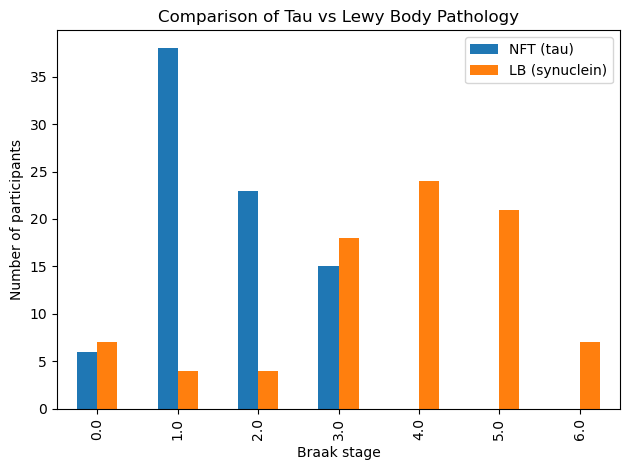

In [27]:
nft_counts = data_i["path_braak_nft"].value_counts().sort_index()
lb_counts  = data_i["path_braak_lb"].value_counts().sort_index()

df_counts = pd.DataFrame({
    "NFT (tau)": nft_counts,
    "LB (synuclein)": lb_counts
}).fillna(0)

df_counts.plot(kind="bar")

plt.xlabel("Braak stage")
plt.ylabel("Number of participants")
plt.title("Comparison of Tau vs Lewy Body Pathology")

plt.tight_layout()
plt.show()

In [33]:
braak_filtered["path_braak_lb"].dropna()

2521    5.0
2522    5.0
2523    5.0
2524    4.0
2525    4.0
       ... 
2605    6.0
2606    6.0
2608    4.0
2609    4.0
2610    5.0
Name: path_braak_lb, Length: 85, dtype: float64

In [37]:
braak_filtered["path_braak_lb"].unique()

array([ 5.,  4.,  3., nan,  2.,  1.,  0.,  6.])

In [29]:
# missing participant ids
set(participant_ids) - set(braak['participant_id'])

{'PM-UM_BEB18119',
 'PM-UM_HCTIX',
 'PM-UM_HCTNJ',
 'PM-UM_HCTTO',
 'PM-UM_HCTWJ',
 'PM-UM_HCTYE'}

In [11]:
adata.X[:10,:10].toarray()

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 2., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 6.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [12]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 9771208829 stored elements and shape (2441192, 40496)>

In [13]:
adata.var.head()

""
featurekey
ENSG00000186827
ENSG00000186891
ENSG00000160072
ENSG00000041988
ENSG00000260179


In [8]:
adata.var.columns

Index(['gene_name', 'n_cells', 'feature_is_filtered', 'feature_name',
       'feature_reference', 'feature_biotype', 'feature_length',
       'feature_type'],
      dtype='object')

In [10]:
adata.layers.keys()

KeysView(Layers with keys: )

In [11]:
adata.obsm.keys()

KeysView(AxisArrays with keys: X_umap)

In [12]:
adata.uns.keys()

dict_keys(['batch_condition', 'citation', 'genome', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'uid'])

In [22]:
adata.uns

{'batch_condition': array(['Brain_bank'], dtype=object),
 'citation': 'Publication: https://doi.org/10.1038/s41597-024-04117-y Dataset Version: https://datasets.cellxgene.cziscience.com/1f51228e-898e-474f-b8f2-5e7ad392b51c.h5ad curated and distributed by CZ CELLxGENE Discover in Collection: https://cellxgene.cziscience.com/collections/d5d0df8f-4eee-49d8-a221-a288f50a1590',
 'genome': 'GRCh38',
 'organism': 'Homo sapiens',
 'organism_ontology_term_id': 'NCBITaxon:9606',
 'schema_reference': 'https://github.com/chanzuckerberg/single-cell-curation/blob/main/schema/6.0.0/schema.md',
 'schema_version': '6.0.0',
 'title': "Parkinson's disease",
 'uid': 'GRCh38-rna'}

In [2]:
 metadata = pd.read_csv('/projects/bioinformatics/DB/scRNAseq_parkinson/metadata.csv')

In [20]:
metadata

,barcodekey,n_genes,n_counts,Brain_bank,RIN,path_braak_lb,derived_class2,PMI,tissue_ontology_term_id,tissue_type,...,suspension_type,is_primary_data,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
0,Set10_C1-AAACCCACATCACGGC,2929,5645.0,UM,4.8,3,Oligo,20.910000,UBERON:0002477,tissue,...,nucleus,True,oligodendrocyte,10x 3' v3,Parkinson disease,male,medial globus pallidus,European,82-year-old stage,MpT)aB)#*U
1,Set10_C1-AAACCCAGTAGCACAG,4395,14741.0,UD,4.4,3,Oligo,20.910000,UBERON:0001384,tissue,...,nucleus,True,oligodendrocyte,10x 3' v3,Parkinson disease,female,primary motor cortex,European,73-year-old stage,qFT~wG^BCg
2,Set10_C1-AAACCCAGTATGTCCA,3856,11005.0,UM,4.8,3,Oligo,20.910000,UBERON:0002477,tissue,...,nucleus,True,oligodendrocyte,10x 3' v3,Parkinson disease,male,medial globus pallidus,European,82-year-old stage,fE`VpY%8fb
3,Set10_C1-AAACCCAGTCCAGAAG,3387,8134.0,UD,4.4,3,Oligo,20.910000,UBERON:0001384,tissue,...,nucleus,True,oligodendrocyte,10x 3' v3,Parkinson disease,female,primary motor cortex,European,73-year-old stage,g1Lr8^y)O(
4,Set10_C1-AAACCCATCCACGTAA,2366,4583.0,UD,4.4,3,Astro,20.910000,UBERON:0001384,tissue,...,nucleus,True,astrocyte,10x 3' v3,Parkinson disease,female,primary motor cortex,European,73-year-old stage,MR9tUCifao
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2096150,set7A_2-TTTGTTGTCAAGAGTA,2976,6626.0,MSSM,4.7,1,Oligo,10.166667,UBERON:0001384,tissue,...,nucleus,True,oligodendrocyte,10x 3' v3,normal,female,primary motor cortex,European,78-year-old stage,25FK4DT!Rl
2096151,set7A_2-TTTGTTGTCACTCTTA,3947,11414.0,MSSM,4.3,2,EN,10.166667,UBERON:0002436,tissue,...,nucleus,True,glutamatergic neuron,10x 3' v3,Parkinson disease,female,primary visual cortex,European,81-year-old stage,PdMVWS9R^v
2096152,set7A_2-TTTGTTGTCAGTGCGC,3212,8142.0,MSSM,3.0,4,Micro_PVM,10.166667,UBERON:0001384,tissue,...,nucleus,True,central nervous system macrophage,10x 3' v3,Parkinson disease,male,primary motor cortex,European,84-year-old stage,Q&?JBHEFAz
2096153,set7A_2-TTTGTTGTCGCCTATC,4442,12156.0,MSSM,4.7,1,OPC,10.166667,UBERON:0001384,tissue,...,nucleus,True,oligodendrocyte precursor cell,10x 3' v3,normal,female,primary motor cortex,European,78-year-old stage,@vUY6<XF#a


In [21]:
adata.raw


In [3]:
for col in metadata.columns:
    print("\n--------------------")
    print("Column:", col)
    print("Unique values:", metadata[col].nunique())
    print(metadata[col].unique()[:20])


--------------------
Column: barcodekey
Unique values: 2096155
['Set10_C1-AAACCCACATCACGGC' 'Set10_C1-AAACCCAGTAGCACAG'
 'Set10_C1-AAACCCAGTATGTCCA' 'Set10_C1-AAACCCAGTCCAGAAG'
 'Set10_C1-AAACCCATCCACGTAA' 'Set10_C1-AAACCCATCTGCTTAT'
 'Set10_C1-AAACGAAAGCGCACAA' 'Set10_C1-AAACGAAAGCTAATCC'
 'Set10_C1-AAACGAACAAGGTTGG' 'Set10_C1-AAACGAACAGAACTTC'
 'Set10_C1-AAACGAAGTGTTGCCG' 'Set10_C1-AAACGAATCCACTGAA'
 'Set10_C1-AAACGAATCCTGTACC' 'Set10_C1-AAACGAATCGACCTAA'
 'Set10_C1-AAACGAATCGCCACTT' 'Set10_C1-AAACGAATCGTAACCA'
 'Set10_C1-AAACGCTAGGGCCTCT' 'Set10_C1-AAACGCTCACGTAACT'
 'Set10_C1-AAACGCTCAGAACTAA' 'Set10_C1-AAACGCTCAGCTCCTT']

--------------------
Column: n_genes
Unique values: 11106
[2929 4395 3856 3387 2366 3727 2795 3482 3781 5025 4596 3023 3538 3910
 3868 3391 3633 4731 4089 2856]

--------------------
Column: n_counts
Unique values: 70803
[ 5645. 14741. 11005.  8134.  4583.  9705.  5710. 10595. 10884. 17836.
 17165.  9309. 10822. 10088. 11710.  7750. 10185. 16218. 12208.  7375.]


# Category Counts

In [4]:
for col in metadata.columns:
    
    if metadata[col].nunique() < 30:
        print("\n==========")
        print("Column:", col)
        print(metadata[col].value_counts())


Column: Brain_bank
Brain_bank
UM         667865
UD         544202
Harvard    455888
MSSM       428200
Name: count, dtype: int64

Column: path_braak_lb
path_braak_lb
4    552929
5    485372
3    381270
0    364445
6    160368
2     87778
1     63993
Name: count, dtype: int64

Column: derived_class2
derived_class2
Oligo        1093520
EN            328856
Astro         227452
IN            152393
Micro_PVM     118515
OPC           112585
Mural          17865
DMNX_Neu       14206
Ependymal      12559
Endo           11070
GPI_Neu         4773
Adaptive        2361
Name: count, dtype: int64

Column: tissue_ontology_term_id
tissue_ontology_term_id
UBERON:0000451    503414
UBERON:0001384    466475
UBERON:0002436    436737
UBERON:0002477    385587
UBERON:0002870    303942
Name: count, dtype: int64

Column: tissue_type
tissue_type
tissue    2096155
Name: count, dtype: int64

Column: assay_ontology_term_id
assay_ontology_term_id
EFO:0009922    2096155
Name: count, dtype: int64

Column: disease_o

In [5]:
summary = pd.DataFrame({
    "column": metadata.columns,
    "dtype": metadata.dtypes.values,
    "missing_values": metadata.isna().sum().values,
    "unique_values": metadata.nunique().values
})

summary.sort_values("unique_values")

,column,dtype,missing_values,unique_values
10,assay_ontology_term_id,object,0,1
9,tissue_type,object,0,1
18,is_primary_data,bool,0,1
17,suspension_type,object,0,1
20,assay,object,0,1
21,disease,object,0,2
15,sex_ontology_term_id,object,0,2
11,disease_ontology_term_id,object,0,2
22,sex,object,0,2
3,Brain_bank,object,0,4


In [6]:
pd.crosstab(metadata["cell_type"], metadata["disease"])

disease,Parkinson disease,normal
cell_type,,
GABAergic neuron,117025,35368
astrocyte,187024,40428
central nervous system macrophage,96514,22001
central nervous system neuron,15011,3968
endothelial cell,8584,2486
ependymal cell,10537,2022
glutamatergic neuron,249928,78928
leukocyte,1729,632
mural cell,13608,4257
